# Final Project: Data Analytics for House Pricing Dataset
## House Sales in King County, USA

**Dataset:** House Sales in King County, USA — homes sold between May 2014 and May 2015 (21,613 records, 21 features).

This notebook covers the complete end-to-end data analysis workflow:
1. Data Understanding & Wrangling
2. Exploratory Data Analysis (EDA)
3. Model Development
4. Model Evaluation and Refinement


## 1. Import Libraries and Load the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score

sns.set(style="whitegrid")
%matplotlib inline


In [2]:
df = pd.read_csv("kc_house_data_NaN.csv")
df.head()


,Unnamed: 0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,7129300520,20141013T000000,221900.0,3.0,1.00,1180,5650,1.0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,6414100192,20141209T000000,538000.0,3.0,2.25,2570,7242,2.0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2,5631500400,20150225T000000,180000.0,2.0,1.00,770,10000,1.0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,3,2487200875,20141209T000000,604000.0,4.0,3.00,1960,5000,1.0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,4,1954400510,20150218T000000,510000.0,3.0,2.00,1680,8080,1.0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


### Question 1: Display the data types of each column

In [3]:
df.dtypes


Unnamed: 0         int64
id                 int64
date                 str
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [4]:
df.describe()


,Unnamed: 0,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21613.00000,2.161300e+04,2.161300e+04,21600.000000,21603.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,10806.00000,4.580302e+09,5.400881e+05,3.372870,2.115736,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,...,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,6239.28002,2.876566e+09,3.671272e+05,0.926657,0.768996,918.440897,4.142051e+04,0.539989,0.086517,0.766318,...,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,0.00000,1.000102e+06,7.500000e+04,1.000000,0.500000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,...,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,5403.00000,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,...,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,10806.00000,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,...,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,16209.00000,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,...,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,21612.00000,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,...,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


## 2. Data Wrangling

The columns `id` and `Unnamed: 0` (a leftover index column) do not contribute to price prediction, so we drop them.


### Question 2: Drop the `id` and `Unnamed: 0` columns, then use `describe()`

In [5]:
df.drop(["id", "Unnamed: 0"], axis=1, inplace=True)
df.describe()


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21600.000000,21603.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.372870,2.115736,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,3.671272e+05,0.926657,0.768996,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,7.500000e+04,1.000000,0.500000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


We can see missing values in `bedrooms` and `bathrooms`.

In [6]:
print("number of NaN values for the column bedrooms :", df["bedrooms"].isnull().sum())
print("number of NaN values for the column bathrooms :", df["bathrooms"].isnull().sum())


number of NaN values for the column bedrooms : 13
number of NaN values for the column bathrooms : 10


Replace the missing values in `bedrooms` and `bathrooms` with the mean of the respective column.

In [7]:
mean_bedrooms = df["bedrooms"].mean()
df["bedrooms"] = df["bedrooms"].fillna(mean_bedrooms)

mean_bathrooms = df["bathrooms"].mean()
df["bathrooms"] = df["bathrooms"].fillna(mean_bathrooms)

print("number of NaN values for the column bedrooms :", df["bedrooms"].isnull().sum())
print("number of NaN values for the column bathrooms :", df["bathrooms"].isnull().sum())


number of NaN values for the column bedrooms : 0
number of NaN values for the column bathrooms : 0


## 3. Exploratory Data Analysis

### Question 3: Count the number of houses with unique floor values, as a dataframe

In [8]:
floor_counts = df["floors"].value_counts().to_frame()
floor_counts.columns = ["counts"]
floor_counts


,counts
floors,
1.0,10680
2.0,8241
1.5,1910
3.0,613
2.5,161
3.5,8


### Question 4: Determine whether houses with a waterfront view have more price outliers

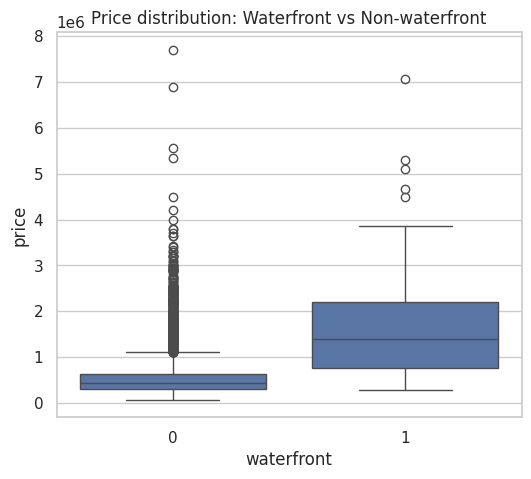

In [9]:
plt.figure(figsize=(6, 5))
sns.boxplot(x="waterfront", y="price", data=df)
plt.title("Price distribution: Waterfront vs Non-waterfront")
plt.show()


**Observation:** Houses with a waterfront view (`waterfront = 1`) show a noticeably higher median price and more high-end outliers than houses without a waterfront view.

### Question 5: Determine whether `sqft_above` is correlated with price

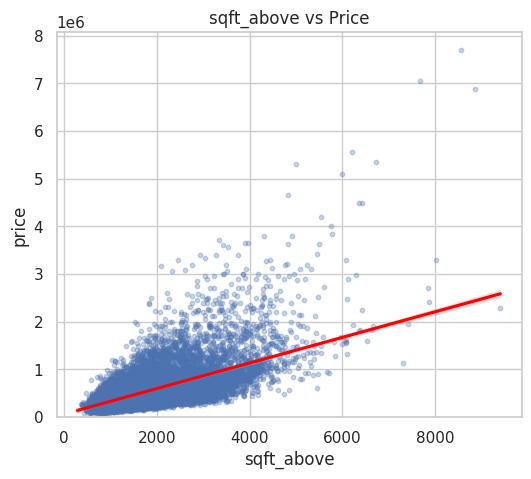

In [10]:
plt.figure(figsize=(6, 5))
sns.regplot(x="sqft_above", y="price", data=df, line_kws={"color": "red"},
            scatter_kws={"alpha": 0.3, "s": 10})
plt.title("sqft_above vs Price")
plt.ylim(0,)
plt.show()


Let's also compute the numerical correlation of every feature with `price`.

In [11]:
df.corr(numeric_only=True)["price"].sort_values(ascending=False)


price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525738
view             0.397293
sqft_basement    0.323816
bedrooms         0.308797
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
zipcode         -0.053203
Name: price, dtype: float64

**Observation:** `sqft_living` shows the strongest positive correlation with `price`, followed by `grade`, `sqft_above`, and `sqft_living15`. `zipcode` shows a very weak (slightly negative) correlation.

## 4. Model Development

### Question 6: Fit a linear regression model using `long` to predict `price`, find R^2

In [12]:
X = df[["long"]]
Y = df["price"]

lm = LinearRegression()
lm.fit(X, Y)
print("R^2 (long -> price):", round(lm.score(X, Y), 5))


R^2 (long -> price): 0.00047


### Question 7: Fit a linear regression model using `sqft_living` to predict `price`, find R^2

In [13]:
X = df[["sqft_living"]]
Y = df["price"]

lm = LinearRegression()
lm.fit(X, Y)
print("R^2 (sqft_living -> price):", round(lm.score(X, Y), 5))


R^2 (sqft_living -> price): 0.49285


### Question 8: Fit a linear regression model to predict `price` using a list of features:
`floors, waterfront, lat, bedrooms, sqft_basement, view, bathrooms, sqft_living15, sqft_above, grade, sqft_living`


In [14]:
features = ["floors", "waterfront", "lat", "bedrooms", "sqft_basement", "view",
            "bathrooms", "sqft_living15", "sqft_above", "grade", "sqft_living"]

X = df[features]
Y = df["price"]

lm = LinearRegression()
lm.fit(X, Y)
print("R^2 (multiple features -> price):", round(lm.score(X, Y), 5))


R^2 (multiple features -> price): 0.6577


### Question 9: Create a pipeline that standardizes the data, performs a polynomial transform,
and fits a linear regression model, using the same list of features.


In [15]:
input_steps = [
    ("scale", StandardScaler()),
    ("polynomial", PolynomialFeatures(include_bias=False)),
    ("model", LinearRegression())
]

pipe = Pipeline(input_steps)
pipe.fit(X, Y)
Yhat = pipe.predict(X)
print("R^2 (pipeline: scale + polynomial + linear regression):", round(r2_score(Y, Yhat), 5))


R^2 (pipeline: scale + polynomial + linear regression): 0.75134


## 5. Model Evaluation and Refinement

### Question 10: Split the data into training and testing sets

In [16]:
features = ["floors", "waterfront", "lat", "bedrooms", "sqft_basement", "view",
            "bathrooms", "sqft_living15", "sqft_above", "grade", "sqft_living"]

X = df[features]
Y = df["price"]

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.15, random_state=1)

print("number of test samples :", x_test.shape[0])
print("number of training samples:", x_train.shape[0])


number of test samples : 3242
number of training samples: 18371


### Question 11: Create and fit a Ridge regression object using the training data, calculate R^2 using the test data

In [17]:
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(x_train, y_train)

r2_ridge = ridge_model.score(x_test, y_test)
print("R^2 with Ridge Regression (alpha=0.1) on test data:", round(r2_ridge, 5))


R^2 with Ridge Regression (alpha=0.1) on test data: 0.64788


### Question 12: Perform a second-order polynomial transform on both the training and testing data,
create and fit a Ridge regression object using the training data, then calculate the R^2 using the test data.


In [18]:
pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train)
x_test_pr = pr.transform(x_test)

ridge_model_poly = Ridge(alpha=0.1)
ridge_model_poly.fit(x_train_pr, y_train)

r2_ridge_poly = ridge_model_poly.score(x_test_pr, y_test)
print("R^2 with Ridge Regression on 2nd-order polynomial features (alpha=0.1):", round(r2_ridge_poly, 5))


R^2 with Ridge Regression on 2nd-order polynomial features (alpha=0.1): 0.70027


### Bonus: Scanning multiple alpha values to find the best Ridge hyperparameter

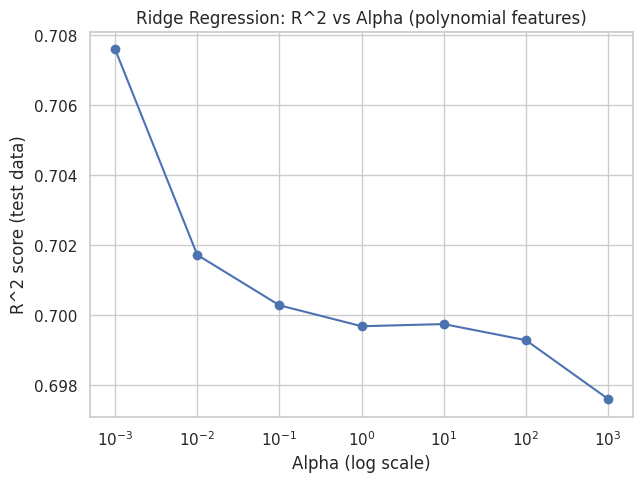

Best alpha: 0.001 -> R^2: 0.70759


In [19]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
r2_scores = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(x_train_pr, y_train)
    r2_scores.append(ridge.score(x_test_pr, y_test))

plt.figure(figsize=(7, 5))
plt.plot(alphas, r2_scores, marker="o")
plt.xscale("log")
plt.xlabel("Alpha (log scale)")
plt.ylabel("R^2 score (test data)")
plt.title("Ridge Regression: R^2 vs Alpha (polynomial features)")
plt.show()

best_alpha = alphas[int(np.argmax(r2_scores))]
print("Best alpha:", best_alpha, "-> R^2:", round(max(r2_scores), 5))


## 6. Results Summary

In [20]:
summary = pd.DataFrame({
    "Model": [
        "Simple Linear Regression (long)",
        "Simple Linear Regression (sqft_living)",
        "Multiple Linear Regression (11 features)",
        "Pipeline (scaled polynomial features)",
        "Ridge Regression (alpha=0.1, test data)",
        "Ridge Regression (2nd-order poly, alpha=0.1, test data)",
        f"Ridge Regression (2nd-order poly, best alpha={best_alpha}, test data)"
    ],
    "R^2 Score": [
        round(LinearRegression().fit(df[["long"]], df["price"]).score(df[["long"]], df["price"]), 5),
        round(LinearRegression().fit(df[["sqft_living"]], df["price"]).score(df[["sqft_living"]], df["price"]), 5),
        round(LinearRegression().fit(df[features], df["price"]).score(df[features], df["price"]), 5),
        round(r2_score(Y, pipe.predict(X)), 5),
        round(r2_ridge, 5),
        round(r2_ridge_poly, 5),
        round(max(r2_scores), 5)
    ]
})
summary


,Model,R^2 Score
0,Simple Linear Regression (long),0.00047
1,Simple Linear Regression (sqft_living),0.49285
2,Multiple Linear Regression (11 features),0.65770
3,Pipeline (scaled polynomial features),0.75134
4,"Ridge Regression (alpha=0.1, test data)",0.64788
5,"Ridge Regression (2nd-order poly, alpha=0.1, t...",0.70027
6,"Ridge Regression (2nd-order poly, best alpha=0...",0.70759


## 7. Conclusion

- **`long` (longitude)** alone is a very weak predictor of `price` (very low R²), since location alone without context (like `lat`) explains little.
- **`sqft_living`** alone is a much stronger single predictor, confirming that the size of the living area is one of the most important price drivers.
- Using **multiple features together** (floors, waterfront, lat, bedrooms, bathrooms, grade, sqft_living, etc.) substantially improves the R² over any single-variable model, since price depends on a combination of size, quality, and location factors.
- Adding **polynomial features** through a pipeline increases the model's fit further on the training data by capturing non-linear relationships and feature interactions.
- **Ridge Regression** helps control the coefficients of the polynomial model, reducing overfitting and improving generalization to the unseen test set.
- Scanning across different **alpha values** shows there is an optimal balance point — too small an alpha behaves like ordinary linear regression (can overfit with polynomial terms), while too large an alpha over-penalizes the coefficients and underfits.
- **Overall**, the polynomial + Ridge regression pipeline, tuned with the right alpha, provides the best trade-off between model complexity and generalization for predicting house prices in this dataset.
